In [1]:
from julia.api import Julia
from julia import Main

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures

import scipy.special as sp
import os

import pathlib
from pathlib import Path
import json

#fitters

import pybobyqa
import time

Which Fit?

In [2]:
fit_name = "Default"
if_grid = True
if_generate_table = False

Initialize Parameters

In [3]:
initial_params = [0.298, 0.803, 0.00192, 0.00325, 0.0182, 0.00909, 1.89, 4.61, 2.77, 0.952, 0.146, 8.71]

Read Files

In [4]:
Main.if_grid = bool(if_grid)
Main.fit_name = str(fit_name)
Main.if_generate_table = bool(if_generate_table)

TMD_fitting_root = "../"
def include(name):
    path = os.path.join(TMD_fitting_root, name)
    Main.eval(f'include(raw"{path}")')

include(f"Cards/{fit_name}.jl")
include("DY/DY_table_FI.jl")

# Data
data_name = Main.data_name
file_root = f"../Data/{data_name}/Cutted/DY"
matrix_root = f"../Data/{data_name}/Covariance_Matrices/DY"
table_root = f"../Tables/{fit_name}/DY"

In [5]:
def to_float64(df):
    num_cols = df.select_dtypes(include=["number"]).columns
    df[num_cols] = df[num_cols].astype("float64")
    return df

df_predictions = dict([])

By file or by experiment?

In [6]:
data_selections = "by_experiment"  # "by_file" or "by_experiment"

In [7]:
experiments =[
    'ATLAS_7',
    'ATLAS_8', 
    'ATLAS_13', 
    'CDF_I',
    'CDF_II',
    'CMS_7',
    'CMS_8',
    'CMS_13',    
    'D0_I',
    'D0_II',
    'D0_II_mu',
    'E288',
    'E605',
    'E772',
    'LHCb_7',
    'LHCb_8',
    'LHCb_13',    
    #'PHENIX',
    'STAR'
]

#["E288","E605","E772","ATLAS", "CMS", "D0", "CDF", "LHCb", "PHENIX", "STAR"]

if data_selections == "by_file":
    file_names = [

    #----------------------------------------------------------------------------
    # ATLAS
    #----------------------------------------------------------------------------

    #"ATLAS/ATLAS_7TeV_y_0_1.csv",
    #"ATLAS/ATLAS_7TeV_y_1_2.csv",
    #"ATLAS/ATLAS_7TeV_y_2_2.4.csv",

    #"ATLAS/ATLAS_8TeV_Q_44_66.csv",
    #"ATLAS/ATLAS_8TeV_Q_116_150.csv",

    #"ATLAS/ATLAS_8TeV_y_0_0.4.csv"
    #"ATLAS/ATLAS_8TeV_y_0.4_0.8.csv"
    #"ATLAS/ATLAS_8TeV_y_0.8_1.2.csv"
    #"ATLAS/ATLAS_8TeV_y_1.2_1.6.csv",
    #"ATLAS/ATLAS_8TeV_y_1.6_2.csv",
    #"ATLAS/ATLAS_8TeV_y_2_2.4.csv",

    #----------------------------------------------------------------------------
    # CDF
    #----------------------------------------------------------------------------

    #"CDF/CDF_RunI.csv",
    #"CDF/CDF_RunII.csv",

    #----------------------------------------------------------------------------
    # CMS
    #----------------------------------------------------------------------------

    #"CMS/CMS_7TeV.csv",
    #"CMS/CMS_8TeV.csv",
    
    #"CMS/CMS_13TeV_y_0_0.4.csv",
    #"CMS/CMS_13TeV_y_0.4_0.8.csv",
    #"CMS/CMS_13TeV_y_0.8_1.2.csv",
    #"CMS/CMS_13TeV_y_1.2_1.6.csv",
    #"CMS/CMS_13TeV_y_1.6_2.4.csv",

    #----------------------------------------------------------------------------
    # D0
    #----------------------------------------------------------------------------

    #"D0/D0_RunI.csv",
    #"D0/D0_RunII.csv",
    #"D0/D0_RunIImu.csv",

    #----------------------------------------------------------------------------
    # LHCb
    #----------------------------------------------------------------------------

    #"LHCb/LHCb_7TeV.csv",
    #"LHCb/LHCb_8TeV.csv",
    #"LHCb/LHCb_13TeV.csv",

    #----------------------------------------------------------------------------
    # Phenix
    #----------------------------------------------------------------------------

    #"PHENIX/PHENIX_200.csv",

    #----------------------------------------------------------------------------
    # STAR
    #----------------------------------------------------------------------------

    #"STAR/STAR_510.csv",

    #----------------------------------------------------------------------------
    # E288
    #----------------------------------------------------------------------------

    #"E288/E288_200_Q_4_5.csv",
    #"E288/E288_200_Q_5_6.csv",
    #"E288/E288_200_Q_6_7.csv",
    #"E288/E288_200_Q_7_8.csv",
    #"E288/E288_200_Q_8_9.csv",
    #"E288/E288_200_Q_10_11.csv",

    #"E288/E288_300_Q_4_5.csv",
    #"E288/E288_300_Q_5_6.csv",
    #"E288/E288_300_Q_6_7.csv",
    #"E288/E288_300_Q_7_8.csv",
    #"E288/E288_300_Q_8_9.csv",
    #"E288/E288_300_Q_10_11.csv",
    #"E288/E288_300_Q_11_12.csv",

    #"E288/E288_400_Q_5_6.csv",
    #"E288/E288_400_Q_6_7.csv",
    #"E288/E288_400_Q_7_8.csv",
    #"E288/E288_400_Q_8_9.csv",
    #"E288/E288_400_Q_10_11.csv",
    #"E288/E288_400_Q_11_12.csv",
    #"E288/E288_400_Q_12_13.csv",
    #"E288/E288_400_Q_13_14.csv",

    #----------------------------------------------------------------------------
    # E605
    #----------------------------------------------------------------------------

    #"E605/E605_Q_7_8.csv",
    #"E605/E605_Q_8_9.csv",
    #"E605/E605_Q_10.5_11.5.csv",
    #"E605/E605_Q_11.5_13.5.csv",
    #"E605/E605_Q_13.5_18.csv",

    #----------------------------------------------------------------------------
    # E772
    #----------------------------------------------------------------------------

    #"E772/E772_Q_5_6.csv",
    #"E772/E772_Q_6_7.csv",
    #"E772/E772_Q_7_8.csv",
    #"E772/E772_Q_8_9.csv",
    #"E772/E772_Q_11_12.csv",
    #"E772/E772_Q_12_13.csv",
    #"E772/E772_Q_13_14.csv",
    #"E772/E772_Q_14_15.csv",
    ]

In [8]:
from pathlib import Path

if data_selections == "by_experiment":
    file_names = []
    for experiment in experiments:
        exp_dir = Path(file_root) / experiment
        for p in sorted(exp_dir.glob("*.csv")):
            file_names.append(str(Path(experiment) / p.name)) 

display(file_names)

['ATLAS_7\\ATLAS7-00y10.csv',
 'ATLAS_7\\ATLAS7-10y20.csv',
 'ATLAS_7\\ATLAS7-20y24.csv',
 'ATLAS_8\\ATLAS8-00y04.csv',
 'ATLAS_8\\ATLAS8-04y08.csv',
 'ATLAS_8\\ATLAS8-08y12.csv',
 'ATLAS_8\\ATLAS8-116Q150.csv',
 'ATLAS_8\\ATLAS8-12y16.csv',
 'ATLAS_8\\ATLAS8-16y20.csv',
 'ATLAS_8\\ATLAS8-20y24.csv',
 'ATLAS_8\\ATLAS8-46Q66.csv',
 'ATLAS_13\\ATLAS13.csv',
 'CDF_I\\CDF1.csv',
 'CDF_II\\CDF2.csv',
 'CMS_7\\CMS7.csv',
 'CMS_8\\CMS8.csv',
 'CMS_13\\CMS13-00y04.csv',
 'CMS_13\\CMS13-04y08.csv',
 'CMS_13\\CMS13-08y12.csv',
 'CMS_13\\CMS13-12y16.csv',
 'CMS_13\\CMS13-16y24.csv',
 'D0_I\\D01.csv',
 'D0_II\\D02.csv',
 'D0_II_mu\\D02mu.csv',
 'E288\\E228-200-4Q5.csv',
 'E288\\E228-200-5Q6.csv',
 'E288\\E228-200-6Q7.csv',
 'E288\\E228-200-7Q8.csv',
 'E288\\E228-200-8Q9.csv',
 'E288\\E228-300-11Q12.csv',
 'E288\\E228-300-4Q5.csv',
 'E288\\E228-300-5Q6.csv',
 'E288\\E228-300-6Q7.csv',
 'E288\\E228-300-7Q8.csv',
 'E288\\E228-300-8Q9.csv',
 'E288\\E228-400-11Q12.csv',
 'E288\\E228-400-12Q13.csv',
 'E

Read Data

In [9]:
data_list = dict()
matrix_list = dict()

for file in tqdm(file_names):

    df_data = to_float64(pd.read_csv(f"{file_root}/{file}"))
    data_list[file] = df_data
    
    matrix = to_float64(pd.read_csv(f"{matrix_root}/{file}"))
    matrix_list[file] = matrix

100%|██████████| 59/59 [00:00<00:00, 413.46it/s]


Read Tables

In [10]:
print("All tables loaded into RAM.")

All tables loaded into RAM.


Prediction

In [11]:
for i in range(10):
    Params = Main.Params_Struct(*[np.float32(x) for x in initial_params])
    Main.set_params(Main.VRAM, Params)
    predictions,t = Main.xsec_dict(Main.rel_paths, Main.VRAM)
    print(round(t*1000,2), "ms")

271.43 ms
36.73 ms
35.96 ms
35.98 ms
36.19 ms
36.25 ms
36.19 ms
35.83 ms
36.31 ms
36.04 ms


In [12]:
display(predictions)

{'..\\Tables\\Default\\DY\\E605\\E605-11.5Q13.5\\1.jls': 0.05933748558163643,
 '..\\Tables\\Default\\DY\\LHCb_8\\LHCb8\\5.jls': 4.527432441711426,
 '..\\Tables\\Default\\DY\\E605\\E605-8Q9\\0.jls': 0.5288140177726746,
 '..\\Tables\\Default\\DY\\CMS_7\\CMS7\\2.jls': 0.05201037973165512,
 '..\\Tables\\Default\\DY\\ATLAS_8\\ATLAS8-00y04\\4.jls': 4.99115514755249,
 '..\\Tables\\Default\\DY\\E288\\E228-300-11Q12\\2.jls': 0.0013224120484665036,
 '..\\Tables\\Default\\DY\\CMS_13\\CMS13-04y08\\2.jls': 8.286113739013672,
 '..\\Tables\\Default\\DY\\D0_II_mu\\D02mu\\0.jls': 0.06538672000169754,
 '..\\Tables\\Default\\DY\\CMS_13\\CMS13-08y12\\6.jls': 7.008444786071777,
 '..\\Tables\\Default\\DY\\CDF_II\\CDF2\\18.jls': 10.570781707763672,
 '..\\Tables\\Default\\DY\\E288\\E228-400-12Q13\\2.jls': 0.0018609303515404463,
 '..\\Tables\\Default\\DY\\STAR\\STAR510\\5.jls': 0.15178945660591125,
 '..\\Tables\\Default\\DY\\ATLAS_7\\ATLAS7-20y24\\1.jls': 0.05487127974629402,
 '..\\Tables\\Default\\DY\\LHCb_8\

In [13]:
def get_file_length():

    file_lengths = dict()

    for file in file_names:

        df = to_float64(pd.read_csv(f"{file_root}/{file}"))

        file_lengths[file] = len(df)

    return file_lengths

file_lengths = get_file_length()

In [14]:
def _norm(p: str) -> str:
    return os.path.normpath(p).replace('\\', '/')

def prediction_reformat(predictions):
    preds = {_norm(k): v for k, v in predictions.items()}  # normalize keys once
    df_predictions = {}

    for file in file_names:
        n = file_lengths[file]
        base = os.path.splitext(file)[0]
        xs = []
        for i in range(n):
            table_path = _norm(os.path.join(table_root, f"{base}/{i}.jls"))
            xs.append(preds[table_path])
        df_predictions[file] = np.array(xs)

    return df_predictions

df_predictions = prediction_reformat(predictions)


Chi2

In [15]:
ASWZ_b_array = np.linspace(0.12,0.78,12)*5.067731
ASWZ_prediction = np.array([
    -0.08158508158508182,
    -0.1701631701631705,
    -0.2400932400932403,
    -0.34265734265734293,
    -0.37062937062937085,
    -0.4265734265734267,
    -0.4498834498834501,
    -0.44522144522144536,
    -0.4965034965034967,
    -0.5710955710955714,
    -0.6363636363636365,
    -0.7016317016317017
    ])
ASWZ_upper = np.array([
    0.18414918414918402,
    0.11421911421911402,
    0.09557109557109533,
    0.002331002331002141,
    0.016317016317016098,
    -0.034965034965035224,
    -0.034965034965035224,
    -0.011655011655011815,
    -0.034965034965035224,
    -0.05361305361305391,
    -0.05827505827505863,
    -0.04895104895104918
    ])
ASWZ_error = np.array(ASWZ_upper) - np.array(ASWZ_prediction)

def chi2_lattice(): 
    CS_list = []
    for b in ASWZ_b_array :
        Q = 2.0
        CS = Main.CS_total_func(b, Q)
        CS_list.append(CS)
    chi2dN = np.sum( (CS_list - ASWZ_prediction)**2 / ASWZ_error**2 ) / len(ASWZ_b_array)
    return chi2dN

def timed(func):
    t0 = time.perf_counter()
    out = func()
    return out, time.perf_counter() - t0

#chi2dN, t = timed(chi2_lattice)
#print("χ^2/N from LATTICE =", chi2dN, ", took", round(t, 4), "seconds")

In [16]:
def get_chi2dN(df_predictions):

    N_list = dict()
    chi2dN_list = dict()
    chi2_total = 0.0
    N_total = 0

    for file in file_names:

        data_xsec = data_list[file]["xsec"].to_numpy()
        pred_xsec = df_predictions[file]
        diff_xsec = data_xsec - pred_xsec

        covariance_matrix_inv = matrix_list[file].to_numpy()

        N = len(data_xsec)

        chi2 = diff_xsec @ covariance_matrix_inv @ diff_xsec

        chi2_total += chi2
        N_total += N
        chi2dN_list[file] = float(round(chi2/N, 2))
        N_list[file] = N

    chi2dN = chi2_total / N_total
    return chi2dN, chi2dN_list, N_list

chi2dN, chi2dN_list, N_list = get_chi2dN(df_predictions)

print(f"Total χ^2/N = {chi2dN:.2f}")
display(chi2dN_list)

Total χ^2/N = 1.02


{'ATLAS_7\\ATLAS7-00y10.csv': 3.0,
 'ATLAS_7\\ATLAS7-10y20.csv': 7.84,
 'ATLAS_7\\ATLAS7-20y24.csv': 4.48,
 'ATLAS_8\\ATLAS8-00y04.csv': 0.18,
 'ATLAS_8\\ATLAS8-04y08.csv': 0.13,
 'ATLAS_8\\ATLAS8-08y12.csv': 0.07,
 'ATLAS_8\\ATLAS8-116Q150.csv': 0.16,
 'ATLAS_8\\ATLAS8-12y16.csv': 0.1,
 'ATLAS_8\\ATLAS8-16y20.csv': 0.22,
 'ATLAS_8\\ATLAS8-20y24.csv': 0.23,
 'ATLAS_8\\ATLAS8-46Q66.csv': 1.38,
 'ATLAS_13\\ATLAS13.csv': 5.36,
 'CDF_I\\CDF1.csv': 1.0,
 'CDF_II\\CDF2.csv': 0.43,
 'CMS_7\\CMS7.csv': 1.58,
 'CMS_8\\CMS8.csv': 1.56,
 'CMS_13\\CMS13-00y04.csv': 0.47,
 'CMS_13\\CMS13-04y08.csv': 0.37,
 'CMS_13\\CMS13-08y12.csv': 0.2,
 'CMS_13\\CMS13-12y16.csv': 0.13,
 'CMS_13\\CMS13-16y24.csv': 0.23,
 'D0_I\\D01.csv': 0.61,
 'D0_II\\D02.csv': 0.81,
 'D0_II_mu\\D02mu.csv': 0.54,
 'E288\\E228-200-4Q5.csv': 0.02,
 'E288\\E228-200-5Q6.csv': 0.44,
 'E288\\E228-200-6Q7.csv': 0.89,
 'E288\\E228-200-7Q8.csv': 0.67,
 'E288\\E228-200-8Q9.csv': 0.4,
 'E288\\E228-300-11Q12.csv': 0.35,
 'E288\\E228-300-4Q5.

Objective

In [17]:
def objective(params):
    Params = Main.Params_Struct(*[np.float32(x) for x in params])  # -> ParamsCL                      # write to device
    Main.set_params(Main.VRAM, Params) 
    predictions, t = Main.xsec_dict(Main.rel_paths, Main.VRAM)
    df_predictions = prediction_reformat(predictions)
    chi2dN, _, _ = get_chi2dN(df_predictions)
    return chi2dN

objective(initial_params)

np.float64(1.0220138344917378)

Bounds

In [18]:
bounds_raw = [
    (0.0, 0.5),   # g2 0.248
    (0.0, 5.0),   # λ 1.82
    (0.0, 0.2),   # λ2 0.0215

    (0.0, 2.0),   # N1 0.316
    (0.0, 2.0),   # N2 0.134
    (0.0, 0.5),   # N3 0.013

    (0.0, 5.0),   # α1 1.29
    (0.0, 10.0),  # α2 4.27
    (0.0, 10.0),  # α3 4.27

    (0.0, 2.0),   # σ1 0.68
    (0.0, 2.0),   # σ2 0.455
    (0.0, 20.0)   # σ3 12.71
]

lower_bounds, upper_bounds = np.array(list(zip(*bounds_raw)))

def objective_normalized(params):

    normalized_params = lower_bounds + params * (upper_bounds - lower_bounds)

    return objective(normalized_params)

def normalize_params(params):
    return (params - lower_bounds) / (upper_bounds - lower_bounds)

def denormalize_params(params):
    return lower_bounds + params * (upper_bounds - lower_bounds)


theta0 = normalize_params(np.array(initial_params))
dim = len(bounds_raw)

Py-Bobyqa Fit

In [19]:
res = pybobyqa.solve(
        objective_normalized, theta0,
        bounds=(np.zeros(dim), np.ones(dim)),
        maxfun=1000,
        rhobeg=0.15,
        rhoend=1e-9,
        scaling_within_bounds=True,
        #seek_global_minimum=True, 
    )

Fit Results

In [20]:
optimal_params_normalized = res.x
optimal_params = denormalize_params(optimal_params_normalized)
best_chi2dN = res.f
N_evals = res.nf

if res.flag == 0:
    print("Optimization successful.")
else:
    print("Optimization failed.")

print()
print("# of Evals =", N_evals)
print()
print("Best χ^2/N =", round(best_chi2dN, 2))
print()
print("Best parameters (normalized):")
print(", ".join(f"{x:.3g}" for x in optimal_params_normalized))
print()
print("Best parameters (unnormalized):")
print(", ".join(f"{x:.3g}" for x in optimal_params))

Optimization successful.

# of Evals = 200

Best χ^2/N = 1.02

Best parameters (normalized):
0.596, 0.159, 0.00958, 0.00159, 0.00904, 0.0181, 0.378, 0.461, 0.277, 0.476, 0.0759, 0.435

Best parameters (unnormalized):
0.298, 0.796, 0.00192, 0.00318, 0.0181, 0.00907, 1.89, 4.61, 2.77, 0.952, 0.152, 8.71


In [21]:
predictions,t = Main.DY_xsec_all_pmap()
df_predictions = prediction_reformat(predictions)
chi2dN, chi2dN_list, N_list = get_chi2dN(df_predictions)

df = pd.DataFrame.from_dict(chi2dN_list, orient="index", columns=["χ^2/N"])
df["N"] = pd.Series(N_list)
df = df.reset_index().rename(columns={"index":"experiment"})
df["experiment"] = df["experiment"].apply(lambda s: Path(s).stem)
df = df[["experiment", "N", "χ^2/N"]]

styled = (
    df.style
      .set_properties(**{"text-align": "center"})           
      .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}])  
)
fmt = {col: "{:.2f}" for col in df.select_dtypes(include="float").columns}
display(styled.format(fmt))

total_N = int(df["N"].sum())
print("Total N:", total_N)

AttributeError: DY_xsec_all_pmap

Plots

In [ ]:
#optimal_params= [0.232, 1.1, 0.0194, 0.171, 0.115, 0.00894, 1.83, 3.42, 2.34, 1.27, 0.0949, 7.82]

In [ ]:
g2, λ, λ2, N1, N2, N3, α1, α2, α3, σ1, σ2, σ3 = optimal_params

Main.eval(fr'''
    @everywhere begin
        NP_g2 = Float32({g2})
        NP_λ  = Float32({λ})
        NP_λ2 = Float32({λ2})
        NP_N1 = Float32({N1});  NP_N2 = Float32({N2});  NP_N3 = Float32({N3})
        NP_α1 = Float32({α1});  NP_α2 = Float32({α2});  NP_α3 = Float32({α3})
        NP_σ1 = Float32({σ1});  NP_σ2 = Float32({σ2});  NP_σ3 = Float32({σ3})
    end
''')

In [ ]:
predictions,t = Main.DY_xsec_all_pmap()
df_predictions = prediction_reformat(predictions)
print("χ^2/N =", round(get_chi2dN(df_predictions)[0],2))

χ^2/N = 1.14


In [ ]:
plots_list = dict([])

for file in file_names:

    df = pd.read_csv(f"{file_root}/{file}")

    qT_array = df["qT_mean"]
    data_array = df["xsec"]
    prediction_array = df_predictions[file]
    
    ratio_array = np.array(prediction_array)/df["xsec"]
    matrix = np.linalg.inv(matrix_list[file].to_numpy())
    error_uncor_array = np.sqrt(np.diag(matrix))
    error_uncor_ratio_array = error_uncor_array/data_array

    df_plot = pd.DataFrame([])

    df_plot["qT_array"] = qT_array
    df_plot["data_array"] = data_array
    df_plot["prediction_array"] = prediction_array
    df_plot["ratio_array"] = ratio_array
    df_plot["error_uncor_array"] = error_uncor_array
    df_plot["error_uncor_ratio_array"] = error_uncor_ratio_array

    plots_list[file] = df_plot

def fmt(x):  
    return f"{float(x):g}"

#for file in list(plots_list.keys()):
#    source_df = pd.read_csv(f"{file_root}/{file}")
#
#    q_bucket = source_df["Q_mean"].round(6)
#    if q_bucket.nunique() == 1:
#        continue
#
#    plot_df = plots_list[file]
#    base_name = Path(file).stem
#
#    for _, row_index in source_df.groupby(q_bucket, sort=False).groups.items():
#        plot_df_split = plot_df.iloc[row_index].reset_index(drop=True)
#
#        qmin_vals = source_df.loc[row_index, "Q_min"].unique()
#        qmax_vals = source_df.loc[row_index, "Q_max"].unique()
#
#        if len(qmin_vals) == 1 and len(qmax_vals) == 1:
#            qmin, qmax = qmin_vals[0], qmax_vals[0]
#        else:
#
#            qmin = source_df.loc[row_index, "Q_min"].min()
#            qmax = source_df.loc[row_index, "Q_max"].max()
#
#        new_key = f"{base_name}_{fmt(qmin)}Q{fmt(qmax)}"
#        plots_list[new_key] = plot_df_split
#
#    del plots_list[file]

C:\Users\congyue zhang\AppData\Local\Temp\ipykernel_16340\3775608151.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


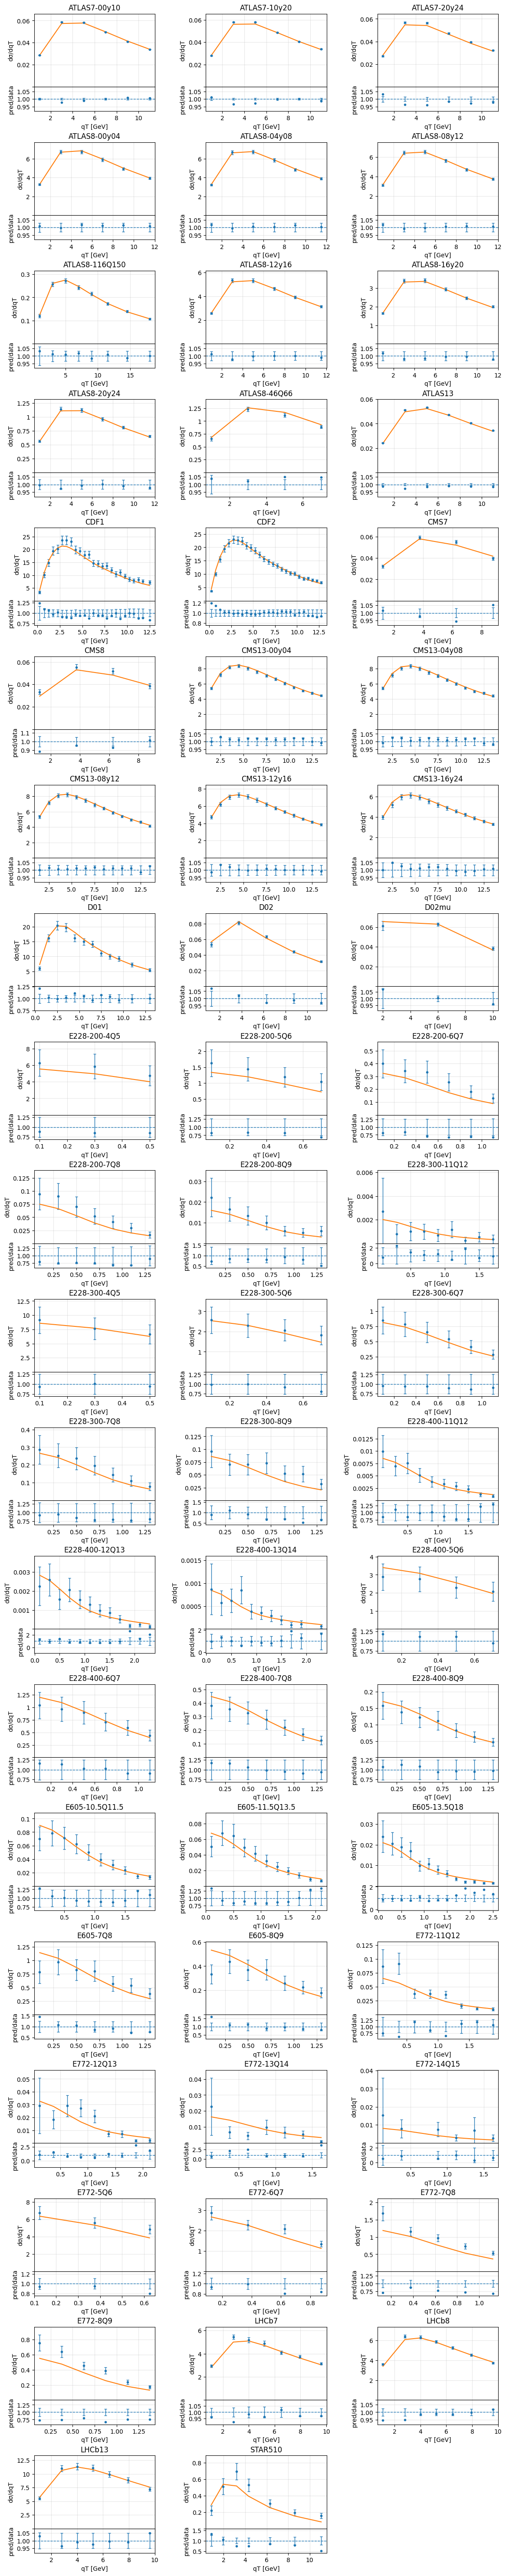

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

# Order to plot (or: sorted(file_names))
files_in_order = list(plots_list.keys())
max_cols_per_row = 3

n_files = len(files_in_order)
if n_files == 0:
    raise ValueError("No files to plot.")

ncols = min(max_cols_per_row, n_files)
nrow_pairs = math.ceil(n_files / ncols)

# Figure & outer grid (spacing BETWEEN files)
fig = plt.figure(figsize=(4.6 * ncols, 3.8 * nrow_pairs))
outer = fig.add_gridspec(nrows=nrow_pairs, ncols=ncols, wspace=0.42, hspace=0.32)

# Hide only the "0" tick label on the spectrum axis
hide_zero_label = FuncFormatter(lambda y, pos: "" if np.isclose(y, 0.0) else f"{y:g}")

def set_spectrum_ylim(ax, y_data, y_err, y_pred, pad_frac=0.12):
    """
    Bottom fixed at 0. Top = max(data+err, prediction) * (1 + pad_frac).
    Purely percentage-based (no fixed absolute padding).
    """
    y_data = np.asarray(y_data, float)
    y_err  = np.asarray(y_err,  float)
    y_pred = np.asarray(y_pred, float)

    data_up = y_data + np.nan_to_num(y_err, nan=0.0)
    candidates = np.concatenate([
        data_up[np.isfinite(data_up)],
        y_pred[np.isfinite(y_pred)]
    ])
    if candidates.size == 0:
        ax.set_ylim(0.0, 1.0)
        return

    ymax = float(np.max(candidates))
    if not np.isfinite(ymax) or ymax <= 0:
        ax.set_ylim(0.0, 1.0)
        return

    ax.set_ylim(0.0, np.nextafter(ymax * (1.0 + pad_frac), np.inf))

def set_ratio_ylim_symmetric_around_one(ax, ratio_vals, ratio_errs,
                                        margin_frac=0.22, min_half_frac=0.08):
    """
    Symmetric about y=1.0, covering ratio points AND 1±err, with percentage-based extra margin.
      - margin_frac: extra headroom as a fraction of the required half-span
      - min_half_frac: minimum half-span as a fraction of 1.0
    """
    r = np.asarray(ratio_vals, float)
    e = np.asarray(ratio_errs, float)
    r_finite = r[np.isfinite(r)]
    e_finite = e[np.isfinite(e)]

    if r_finite.size == 0 and e_finite.size == 0:
        half = max(min_half_frac, 0.10)
        ax.set_ylim(1.0 - half, 1.0 + half)
        return

    lower_from_points = np.min(r_finite) if r_finite.size else np.inf
    upper_from_points = np.max(r_finite) if r_finite.size else -np.inf

    if e_finite.size:
        max_err = float(np.nanmax(e_finite))
        lower_from_errors = 1.0 - max_err
        upper_from_errors = 1.0 + max_err
    else:
        lower_from_errors = np.inf
        upper_from_errors = -np.inf

    lower = min(lower_from_points, lower_from_errors)
    upper = max(upper_from_points, upper_from_errors)

    half_needed = max(1.0 - lower, upper - 1.0, 0.0)
    half = max(half_needed * (1.0 + margin_frac), min_half_frac)
    ax.set_ylim(1.0 - half, 1.0 + half)

for idx, fname in enumerate(files_in_order):
    r = idx // ncols
    c = idx % ncols

    # Inner grid per file: top+bottom, zero vertical gap; share x within the pair
    inner = outer[r, c].subgridspec(nrows=2, ncols=1, height_ratios=[3, 1], hspace=0.0)
    ax_top = fig.add_subplot(inner[0, 0])
    ax_bot = fig.add_subplot(inner[1, 0], sharex=ax_top)

    plot_df = plots_list[fname]
    qT         = plot_df["qT_array"].to_numpy()
    data_vals  = plot_df["data_array"].to_numpy()
    pred_vals  = np.asarray(plot_df["prediction_array"], float)
    data_err   = plot_df["error_uncor_array"].to_numpy()
    ratio_vals = plot_df["ratio_array"].to_numpy()
    ratio_errs = plot_df["error_uncor_ratio_array"].to_numpy()

    # --- Top: data ± error vs prediction ---
    ax_top.errorbar(qT, data_vals, yerr=data_err, fmt='o', ms=3, elinewidth=1, capsize=2, label="data")
    ax_top.plot(qT, pred_vals, linewidth=1.5, label="prediction")
    ax_top.set_title(Path(fname).stem)
    ax_top.set_ylabel("dσ/dqT")
    ax_top.grid(True, alpha=0.3)
    set_spectrum_ylim(ax_top, data_vals, data_err, pred_vals)     # starts at 0, % headroom
    ax_top.yaxis.set_major_formatter(hide_zero_label)             # hide "0" label
    ax_top.tick_params(labelbottom=False)                         # no x labels on top panel
    # show the separator line between panels (keep both spines visible)
    ax_top.spines['bottom'].set_visible(True)
    #if idx == 0:
    #    ax_top.legend(frameon=False)

    # --- Bottom: ratio, symmetric about 1.0 with % margin ---
    ax_bot.axhline(1.0, linestyle="--", linewidth=1)
    ax_bot.plot(qT, ratio_vals, marker='o', linestyle='none', ms=3)
    ax_bot.errorbar(qT, np.ones_like(qT), yerr=ratio_errs, fmt='none', elinewidth=1, capsize=2)
    ax_bot.set_xlabel("qT [GeV]")
    ax_bot.set_ylabel("pred/data")
    ax_bot.grid(True, alpha=0.3)
    set_ratio_ylim_symmetric_around_one(ax_bot, ratio_vals, ratio_errs,
                                        margin_frac=0.22, min_half_frac=0.08)
    ax_bot.spines['top'].set_visible(True)  # separator remains visible

plt.tight_layout()
plt.show()